In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [2]:
data2 = r"C:\Users\rajeshkumar.t\Downloads\6025ac4bfe90ad7c55f5526d6e9af44a.csv"
df = pd.read_csv(data2).replace("noData", np.nan)
df = df.drop(columns=['listing_quality_score', 'cluster','brand'])
#print(df.isna().sum())
before =df.shape[0]
print(before)

200000


In [3]:
target = 'promise_breach'
features  = ['gmv', 'mrp', 'listing_price', 'sla_in_days', 'shipment_type', 'city_tier', 'courier_name','order_billing_amount', 'category_id', 'marketplace_id',
       'order_sales_channel']
#df = df.dropna(subset=[target])
after = df.shape[0]
print(after)

200000


In [4]:
print(before-after)
print(df.dtypes)

0
oms_version               float64
id                         object
order_item_id              object
type                       object
flow_type                  object
                           ...   
order_sales_experience     object
order_tags                 object
unit_tags                  object
is_extra_saver_flag          bool
order_date_key              int64
Length: 223, dtype: object


In [5]:
le = LabelEncoder()
for col in ['courier_name', 'shipment_type', 'order_sales_channel', 'category_id','city_tier','marketplace_id']:
    df[col] = le.fit_transform(df[col].astype(str))
le_target = LabelEncoder()
df['promise_breach'] = le_target.fit_transform(df['promise_breach'].astype(str))

In [6]:
#print(dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))
reverse_mapping = dict(zip(le_target.classes_, range(len(le_target.classes_))))
print(reverse_mapping)

{'Ahead': 0, 'Breach': 1, 'Met': 2, 'nan': 3}


In [7]:
df[features] =df[features].fillna(df[features].median())
feature_after = df.shape[0]
print(df.dtypes)


oms_version               float64
id                         object
order_item_id              object
type                       object
flow_type                  object
                           ...   
order_sales_experience     object
order_tags                 object
unit_tags                  object
is_extra_saver_flag          bool
order_date_key              int64
Length: 223, dtype: object


In [8]:
X = df[features]
y = df[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test=  train_test_split(X_scaled, y, test_size = 0.2, random_state= 42)
knn =KNeighborsClassifier(n_neighbors=5, metric = 'euclidean')
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(f"KNN Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\n Classification Reports:", classification_report(y_test, y_pred))

KNN Accuracy: 0.7845

 Classification Reports:               precision    recall  f1-score   support

           0       0.55      0.66      0.60      7140
           1       0.15      0.04      0.07      1645
           2       0.87      0.87      0.87     24505
           3       0.81      0.79      0.80      6710

    accuracy                           0.78     40000
   macro avg       0.60      0.59      0.59     40000
weighted avg       0.77      0.78      0.78     40000



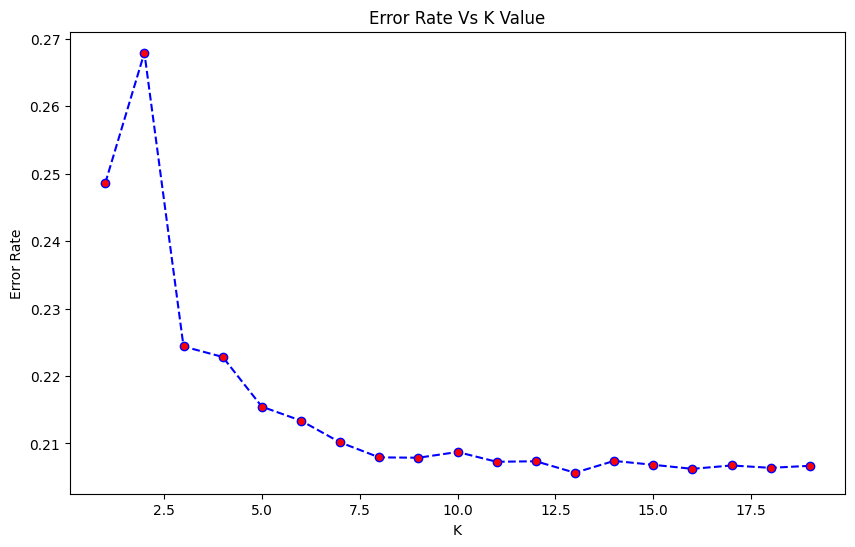

In [9]:
error_rate = []
for i in range(1,20):
    knn_i = KNeighborsClassifier(n_neighbors=i)
    knn_i.fit(X_train, y_train)
    pred_i = knn_i.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))
plt.figure(figsize=(10,6))
plt.plot(range(1,20), error_rate, color='blue', linestyle = 'dashed', marker='o', markerfacecolor='red')
plt.title("Error Rate Vs K Value")
plt.xlabel("K")
plt.ylabel("Error Rate")
plt.show()


                 
    

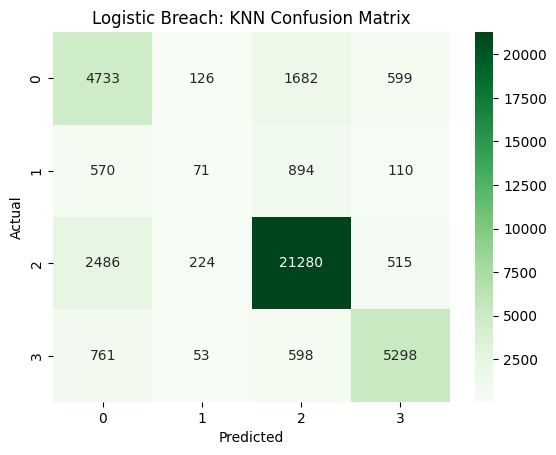

In [11]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='g', cmap='Greens')
plt.title("Logistic Breach: KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [16]:
import pandas as pd
train_data = pd.DataFrame(X_train)
train_data['target'] =y_train.values
balanced_data = train_data.groupby('target').sample(n=train_data['target'].value_counts().min(), random_state=42)

X_trained_balanced = balanced_data.drop('target', axis=1).values
y_trained_balanced = balanced_data['target'].values

knn_tuned = KNeighborsClassifier(n_neighbors=5, weights= 'distance', metric = 'euclidean')
knn_tuned.fit(X_trained_balanced, y_trained_balanced)
y_pred_tuned = knn_tuned.predict(X_test)
print(f"Tuned Knn accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print("\n Tuned Classification Report:\n", classification_report(y_test, y_pred_tuned))

Tuned Knn accuracy: 0.6581

 Tuned Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.57      0.55      7140
           1       0.09      0.45      0.15      1645
           2       0.95      0.67      0.79     24505
           3       0.74      0.76      0.75      6710

    accuracy                           0.66     40000
   macro avg       0.58      0.61      0.56     40000
weighted avg       0.81      0.66      0.71     40000



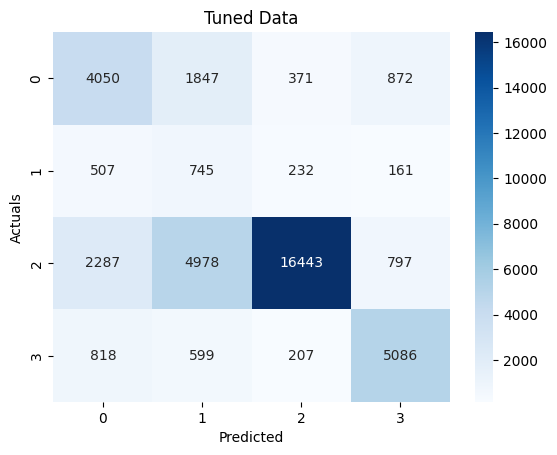

In [20]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='g', cmap='Blues')
plt.title("Tuned Data")
plt.xlabel("Predicted")
plt.ylabel("Actuals")
plt.show()

In [23]:
#from imblearn.over_sampling import SMOTE
#smote = SMOTE(random_state = 42)
#X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

#knn_tuned = KNeighborsClassifiers(n_neighbors = 5, weights = 'distance' , metric = 'euclidean')
#knn_tuned.fit(X_train_smote, y_train_smote)

y_pred_tuned = knn_tuned_predict(X_test)
print(f"Knn accoracy using smote: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"\n Classification Report:\n" , classification_report(y_test, y_pred_tuned))

NameError: name 'knn_tuned_predict' is not defined